# AIMS4PT Calculator

This jupyter notebook provides a calculator for the AIMS4PT framework. It allows users to input various parameters and calculates the results based on the AIMS4PT model.

Before using the calculator, please ensure you have installed the AIMS4PT package following README.md instructions.

只有标记了 `Input required` 的部分需要你手动输入内容，其他部分是代码实现细节，你可以选择性查看。

指定 project name， 这样我们可以保存你的计算结果到 `report_output` 文件夹下，文件名包含 project name 和时间戳，方便你后续查找和使用。
如果改变input/settings, 请务必修改 project name，或者删除之前的计算cache (.pkl)文件

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import pickle as pkl
from aims4pt.reporting.excel import report_excel
from aims4pt.model_tools.CpxTBSelect import workflow_thermobarometry

timestamp = time.strftime("%Y%m%d-%H%M%S")
timestamp

'20260513-171646'

# Step 1: Input your data and basic settings
Input your data in the `input.xlsx` file and run the following code to load it into the notebook.

input.xlsx 目前包含一些例子数据，您可以根据需要修改这些数据。请确保输入的数据格式正确。all in wt%



In [2]:
input_path = 'input.xlsx'
input_data = pd.read_excel(input_path, skiprows=1)  # Skip the first row (header)

# Extracting column ending with _cpx from the input data
X_cpx = input_data.loc[:, input_data.columns.str.endswith('_cpx')]
X_liq = input_data.loc[:, input_data.columns.str.endswith('_liq')]


In [3]:
X_cpx.head()

,SiO2_cpx,TiO2_cpx,Al2O3_cpx,FeOt_cpx,MnO_cpx,MgO_cpx,CaO_cpx,Na2O_cpx,K2O_cpx,Cr2O3_cpx
0,52.06,0.83,3.98,7.72,0.22,15.44,20.33,0.35,0.06,NaN
1,50.74,0.81,3.47,10.20,0.21,16.28,18.12,0.29,0.02,NaN
2,50.45,0.94,2.75,11.38,0.37,15.88,17.17,0.30,0.06,NaN
3,52.10,0.51,2.57,6.69,0.23,16.52,20.39,0.27,0.04,NaN
4,51.44,0.76,3.57,9.29,0.26,16.72,17.70,0.25,0.05,NaN


In [4]:
# auto detect if X_liq is empty
X_liq_empty = X_liq["SiO2_liq"].isnull().all()  # Assuming SiO2_liq is a key column to check
# auto detect if H2O_liq is empty
X_water_empty = X_liq["H2O_liq"].isnull().all() 


X_liq.head()

,SiO2_liq,TiO2_liq,Al2O3_liq,FeOt_liq,MnO_liq,MgO_liq,CaO_liq,Na2O_liq,K2O_liq,Cr2O3_liq,P2O5_liq,H2O_liq
0,59.97,0.87,17.37,6.27,0.13,2.89,6.30,4.03,1.90,NaN,0.27,0
1,61.36,0.96,16.51,6.26,0.12,2.46,5.62,4.11,2.25,NaN,0.34,0
2,63.91,0.95,16.28,5.22,0.09,1.63,4.22,4.50,2.78,NaN,0.40,0
3,60.19,0.88,16.84,6.08,0.14,3.42,6.71,3.89,1.71,NaN,0.13,0
4,60.10,0.94,17.66,5.94,0.13,2.91,6.25,4.10,1.82,NaN,0.16,0


## 1.1. (Input required, optional) melt TAS fields

Please input the assumed **melt TAS fields** for melt composition TAS OOD check, if liquid composition is not provided. 

从下面的字段来选：
VALID_MELT_TAS_FIELDS = (
    "Picrite",
    "Basalt",
    "Basaltic Andesite",
    "Andesite",
    "Dacite",
    "Rhyolite",
    "Foidite",
    "Trachyte",
    "Trachybasalt",
    "Basaltic Trachyandesite",
    "Trachyandesite",
    "Tephrite–Basanite",
    "Phonotephrite",
    "Tephriphonolite",
    "Phonolite",
)
以list格式输入，e.g., TAS_fields = ['Basalt', 'Andesite', ]

In [5]:
# Default melt TAS fields:
TAS_fields = ['Basalt', 'Andesite', ] # Change this list to the assumed **melt TAS fields** for your data 



## 1.2. (Input required) Basic settings for AIMS4PT framework



In [6]:
# whether to calculate the P-T from clinopyroxene-liquid barometry/thermometry
calculate_cpx_liq = True

# Project name for output file naming and save your results
project_name = "example_project"  # Change this to your project name

# Step 2: Run the AIMS4PT calculator
Run the following code to execute the AIMS4PT calculator with your input data and settings. The results will be saved in the `report_output` folder as an excel file.

In [7]:
# create output directory if not exist
output_dir = os.path.join("report_output", project_name)
os.makedirs(output_dir, exist_ok=True)

## 2.1. Initialize all models

In [ ]:
from aims4pt.model_tools.model_registry import  get_models_initial_pools, ALL_MODELS_MODULES


import importlib
for module in ALL_MODELS_MODULES:
    importlib.import_module(module)

P_model_pool = get_models_initial_pools("P", "both" , False) # get all P models including cpx_only and cpx_liq
P_model_names = list(model.model_name for model in P_model_pool)
T_model_pool = get_models_initial_pools("T", "both" , False) # get all T models including cpx_only and cpx_liq
T_model_names = list(model.model_name for model in T_model_pool)

# you could exclude some models if you don't want to use them, for example:
# models_to_exclude = ["Brugman & Till, 2019 (cpx_liq)", ]  # example model names to exclude
# P_model_pool = [model for model in P_model_pool if model.model_name not in models_to_exclude]
# T_model_pool = [model for model in T_model_pool if model.model_name not in models_to_exclude]
# P_model_names = list(model.model_name for model in P_model_pool)
# T_model_names = list(model.model_name for model in T_model_pool)

[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[Skip] Error initializing model Brugman_Till_19: Brugman_Till_19 only supports temperature (T) calculations, not pressure (P) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

[skipped] Error initializing model <class 'aims4pt.model_tools.Neave_Putirka_17.Neave_Putirka_17'> with T: Pu08_eq33_T, P: eq1_P - Neave_Putirka_17 only supports pressure (P) calculations, not temperature (T) calculations.


c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\13493\miniconda3\envs\AIMS4PT\lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator OneClassSVM from version 1.7.2 when using ver

In [9]:
# print all models in the pool
# you can check the model names here
P_model_pool

[
         ModelManager: Putirka_08
         Model name: Putirka, 2008 eq32d_T; eq32a_P (cpx_only)
         interested parameter: P; cpx-only
         require_water: False
         uncertainty: 3.1 kbar
         comment: None
         ,
 
         ModelManager: Putirka_08
         Model name: Putirka, 2008 eq32d_T; eq32b_P (cpx_only)
         interested parameter: P; cpx-only
         require_water: True
         uncertainty: 2.6 kbar
         comment: None
         ,
 
         ModelManager: Petrelli20
         Model name: Petrelli et al., 2020 (cpx_only)
         interested parameter: P; cpx-only
         require_water: False
         uncertainty: 3.2 kbar
         comment: None
         ,
 
         ModelManager: Higgins21
         Model name: Higgins et al., 2021 (cpx_only)
         interested parameter: P; cpx-only
         require_water: False
         uncertainty: 2.3 kbar
         comment: None
         ,
 
         ModelManager: Jorgenson22
         Model name: Jorgenson et al

In [10]:
T_model_pool

[
         ModelManager: Putirka_08
         Model name: Putirka, 2008 eq32d_T; eq32a_P (cpx_only)
         interested parameter: T; cpx-only
         require_water: False
         uncertainty: 58 ℃
         comment: None
         ,
 
         ModelManager: Putirka_08
         Model name: Putirka, 2008 eq32d_T; eq32b_P (cpx_only)
         interested parameter: T; cpx-only
         require_water: True
         uncertainty: 58 ℃
         comment: None
         ,
 
         ModelManager: Petrelli20
         Model name: Petrelli et al., 2020 (cpx_only)
         interested parameter: T; cpx-only
         require_water: False
         uncertainty: 96 ℃
         comment: None
         ,
 
         ModelManager: Higgins21
         Model name: Higgins et al., 2021 (cpx_only)
         interested parameter: T; cpx-only
         require_water: False
         uncertainty: 57 ℃
         comment: None
         ,
 
         ModelManager: Jorgenson22
         Model name: Jorgenson et al., 2022 (cpx_onl

## 2.2. Clinopyroxene-only barometry/thermometry calculation 

### 2.2.1. Barometers

Loaded existing workflow from: report_output\example_project\computed_cache_cpx_only_P.pkl


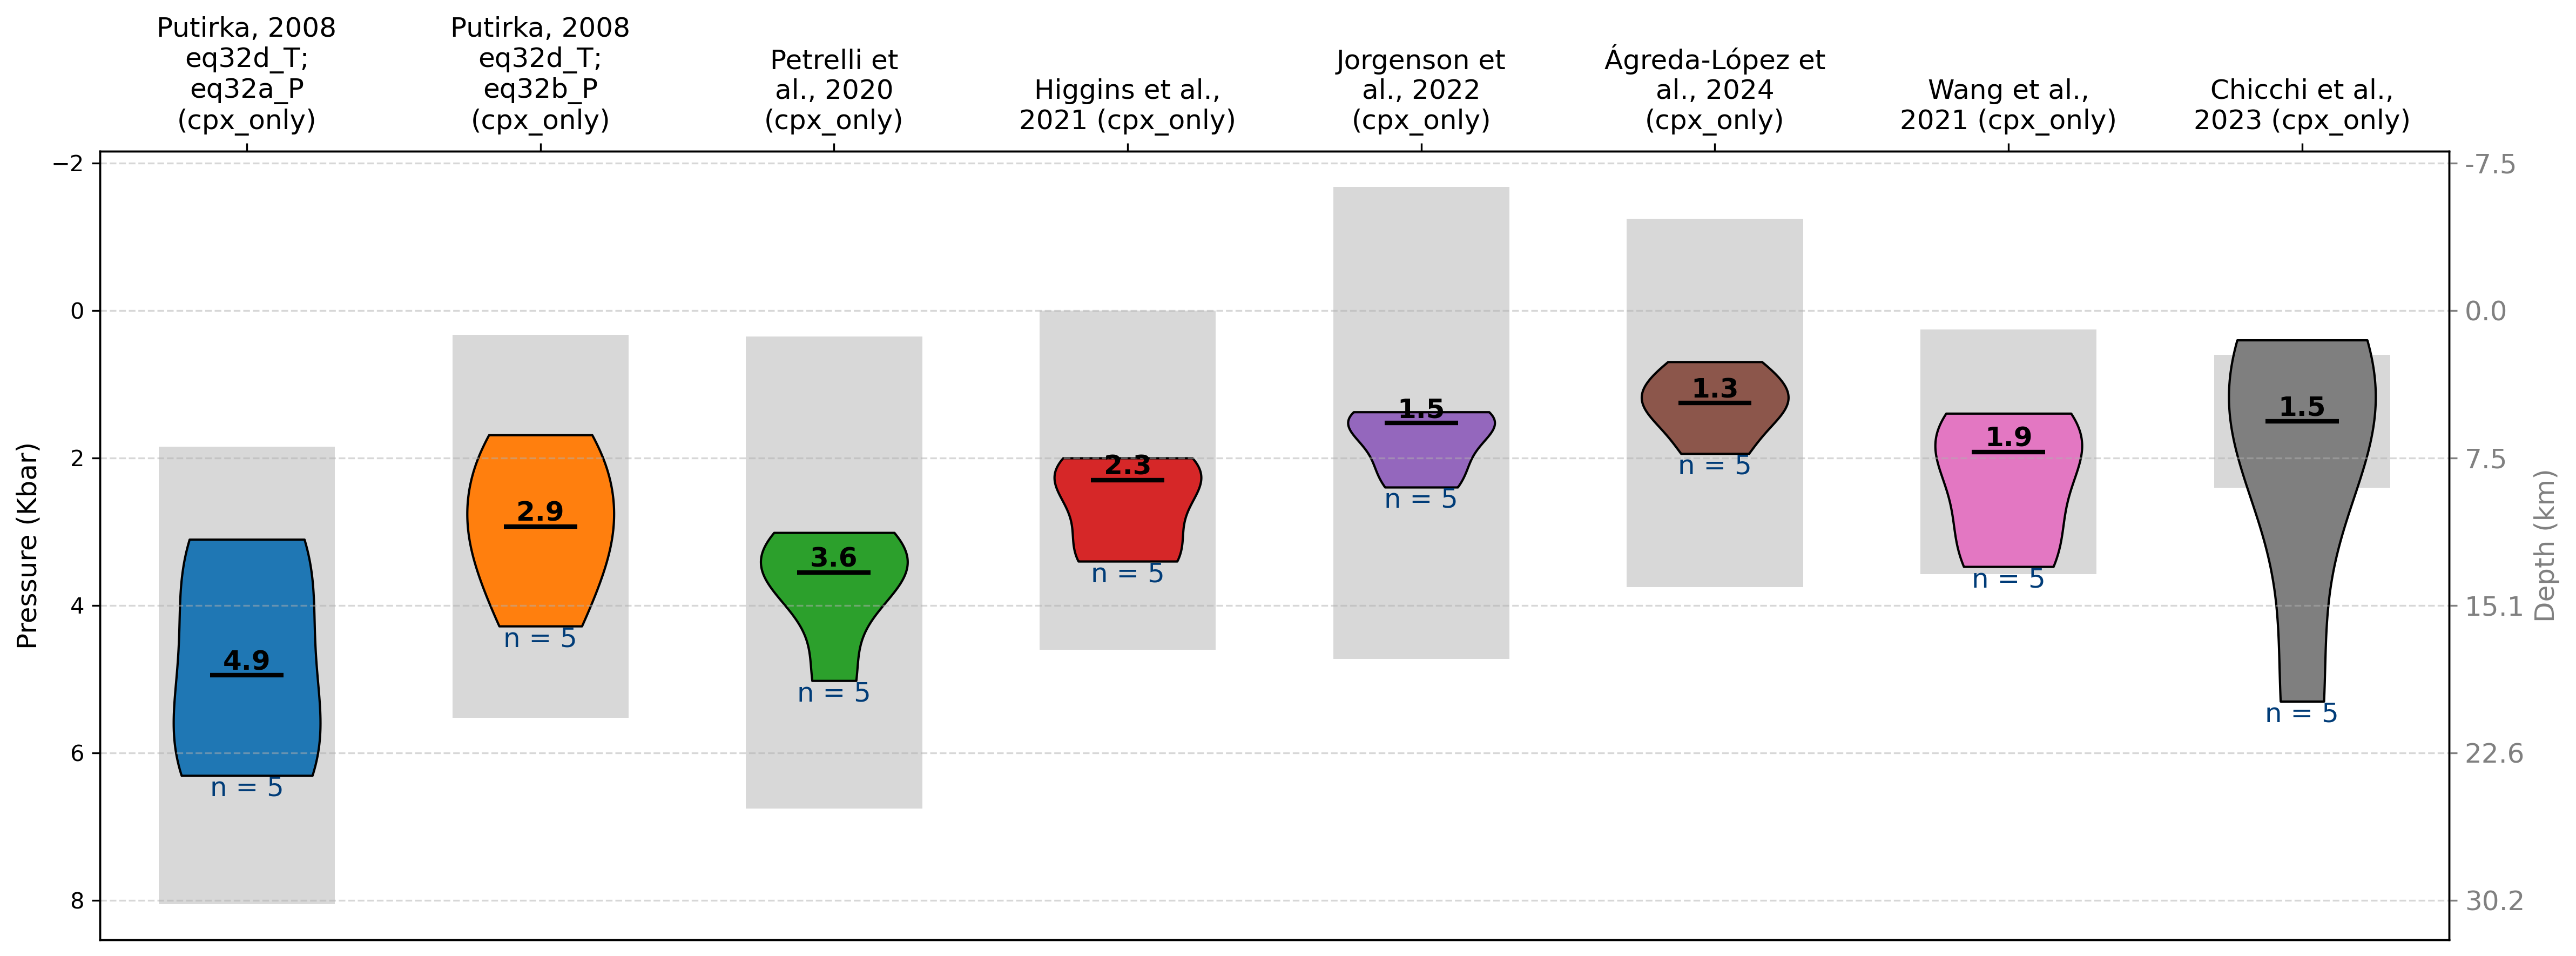

In [ ]:

P_cpx_only_pool = [model for model in P_model_pool if model.cpx_only]

cache_path_P_only = os.path.join(output_dir, f"computed_cache_cpx_only_P.pkl")


if os.path.exists(cache_path_P_only):
    with open(cache_path_P_only, 'rb') as f:
        framework_P_cpx_only = pkl.load(f)
    print("Loaded existing workflow from:", cache_path_P_only)
else:
    framework_P_cpx_only = workflow_thermobarometry(P_cpx_only_pool)
    if X_liq_empty:
        # If liquid data is empty, only use melt TAS for OOD checking
        framework_P_cpx_only.predict(X_cpx, X_liq, input_melt_TAS=TAS_fields, melt_TAS_source = "input_melt_TAS")
    else:
        # else use liquid data for OOD checking
        framework_P_cpx_only.predict(X_cpx, X_liq)
    with open(cache_path_P_only, 'wb') as f:
        pkl.dump(framework_P_cpx_only, f)
    print("Saved workflow to:", cache_path_P_only)




report_path_P_only = os.path.join(output_dir, f"{timestamp}_report_cpx_only_P.xlsx")

report_excel(
    workflow_obj=framework_P_cpx_only,
    model_list =P_cpx_only_pool,
    original_data=input_data,
    out_path=report_path_P_only
)


### 2.2.2. Thermometers

Saved workflow to: report_output\example_project\computed_cache_cpx_only_T.pkl


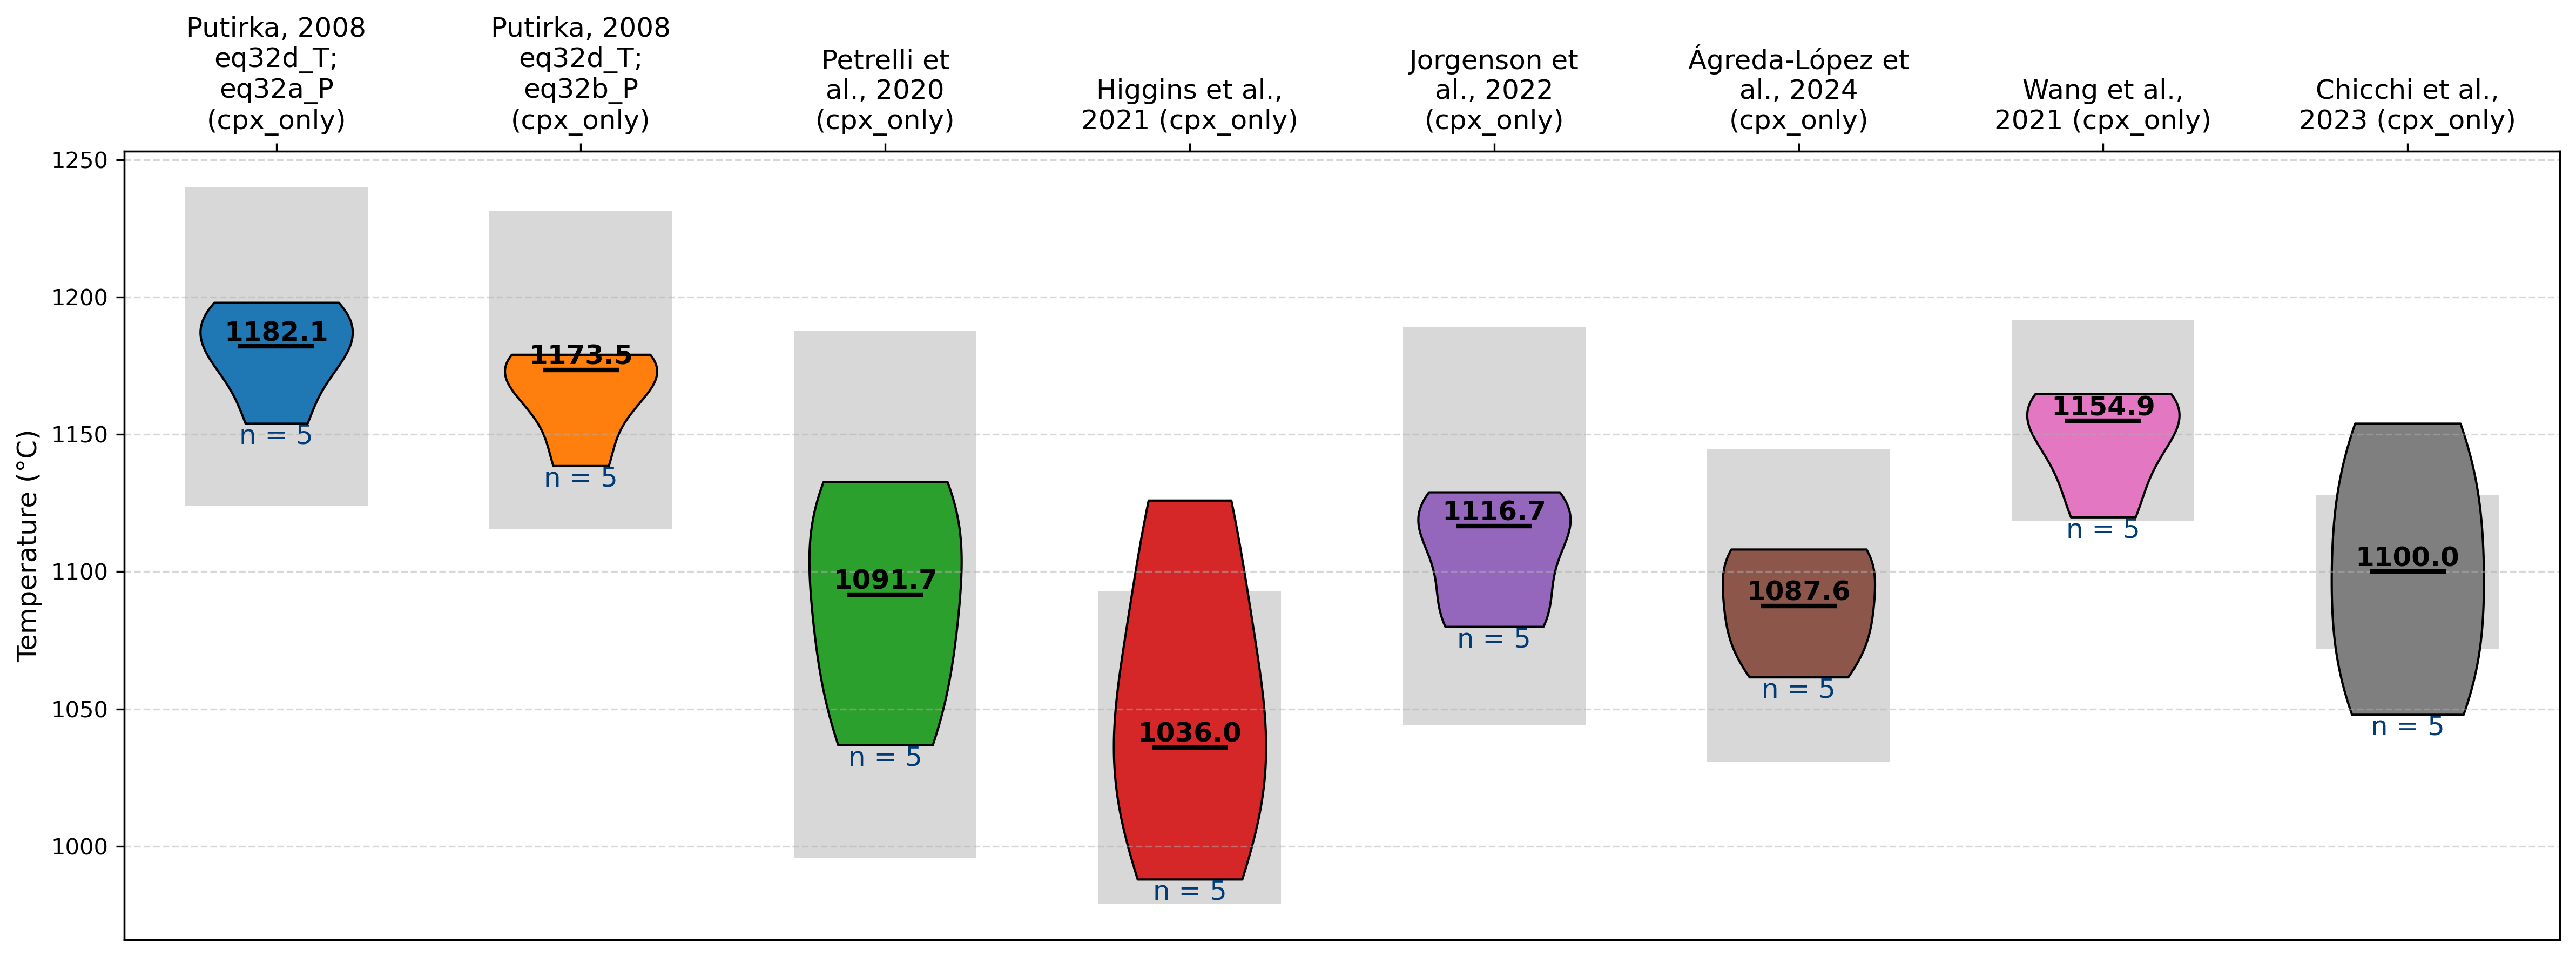

In [ ]:

T_cpx_only_pool = [model for model in T_model_pool if model.cpx_only]

cache_path_T_only = os.path.join(output_dir, f"computed_cache_cpx_only_T.pkl")


if os.path.exists(cache_path_T_only):
    with open(cache_path_T_only, 'rb') as f:
        framework_T_cpx_only = pkl.load(f)
    print("Loaded existing workflow from:", cache_path_T_only)
else:
    framework_T_cpx_only = workflow_thermobarometry(T_cpx_only_pool)
    if X_liq_empty:
        # If liquid data is empty, only use melt TAS for OOD checking
        framework_T_cpx_only.predict(X_cpx, X_liq, input_melt_TAS=TAS_fields, melt_TAS_source = "input_melt_TAS")
    else:
        # else use liquid data for OOD checking
        framework_T_cpx_only.predict(X_cpx, X_liq)
    with open(cache_path_T_only, 'wb') as f:
        pkl.dump(framework_T_cpx_only, f)
    print("Saved workflow to:", cache_path_T_only)




report_path_T_only = os.path.join(output_dir, f"{timestamp}_report_cpx_only_T.xlsx")

report_excel(
    workflow_obj=framework_T_cpx_only,
    model_list =T_cpx_only_pool,
    original_data=input_data,
    out_path=report_path_T_only
)


## 2.3. Clinopyroxene-liquid barometry/thermometry calculation (Run this part only if you have liquid data)

In [ ]:
# Warn user and stop the code if X_liq_empty
if X_liq.empty:
    raise ValueError("No liquid data detected. Clinopyroxene-liquid barometry/thermometry will not be calculated.")

### 2.2.1. Barometers

Saved workflow to: report_output\example_project\computed_cache_cpx_liq_P.pkl


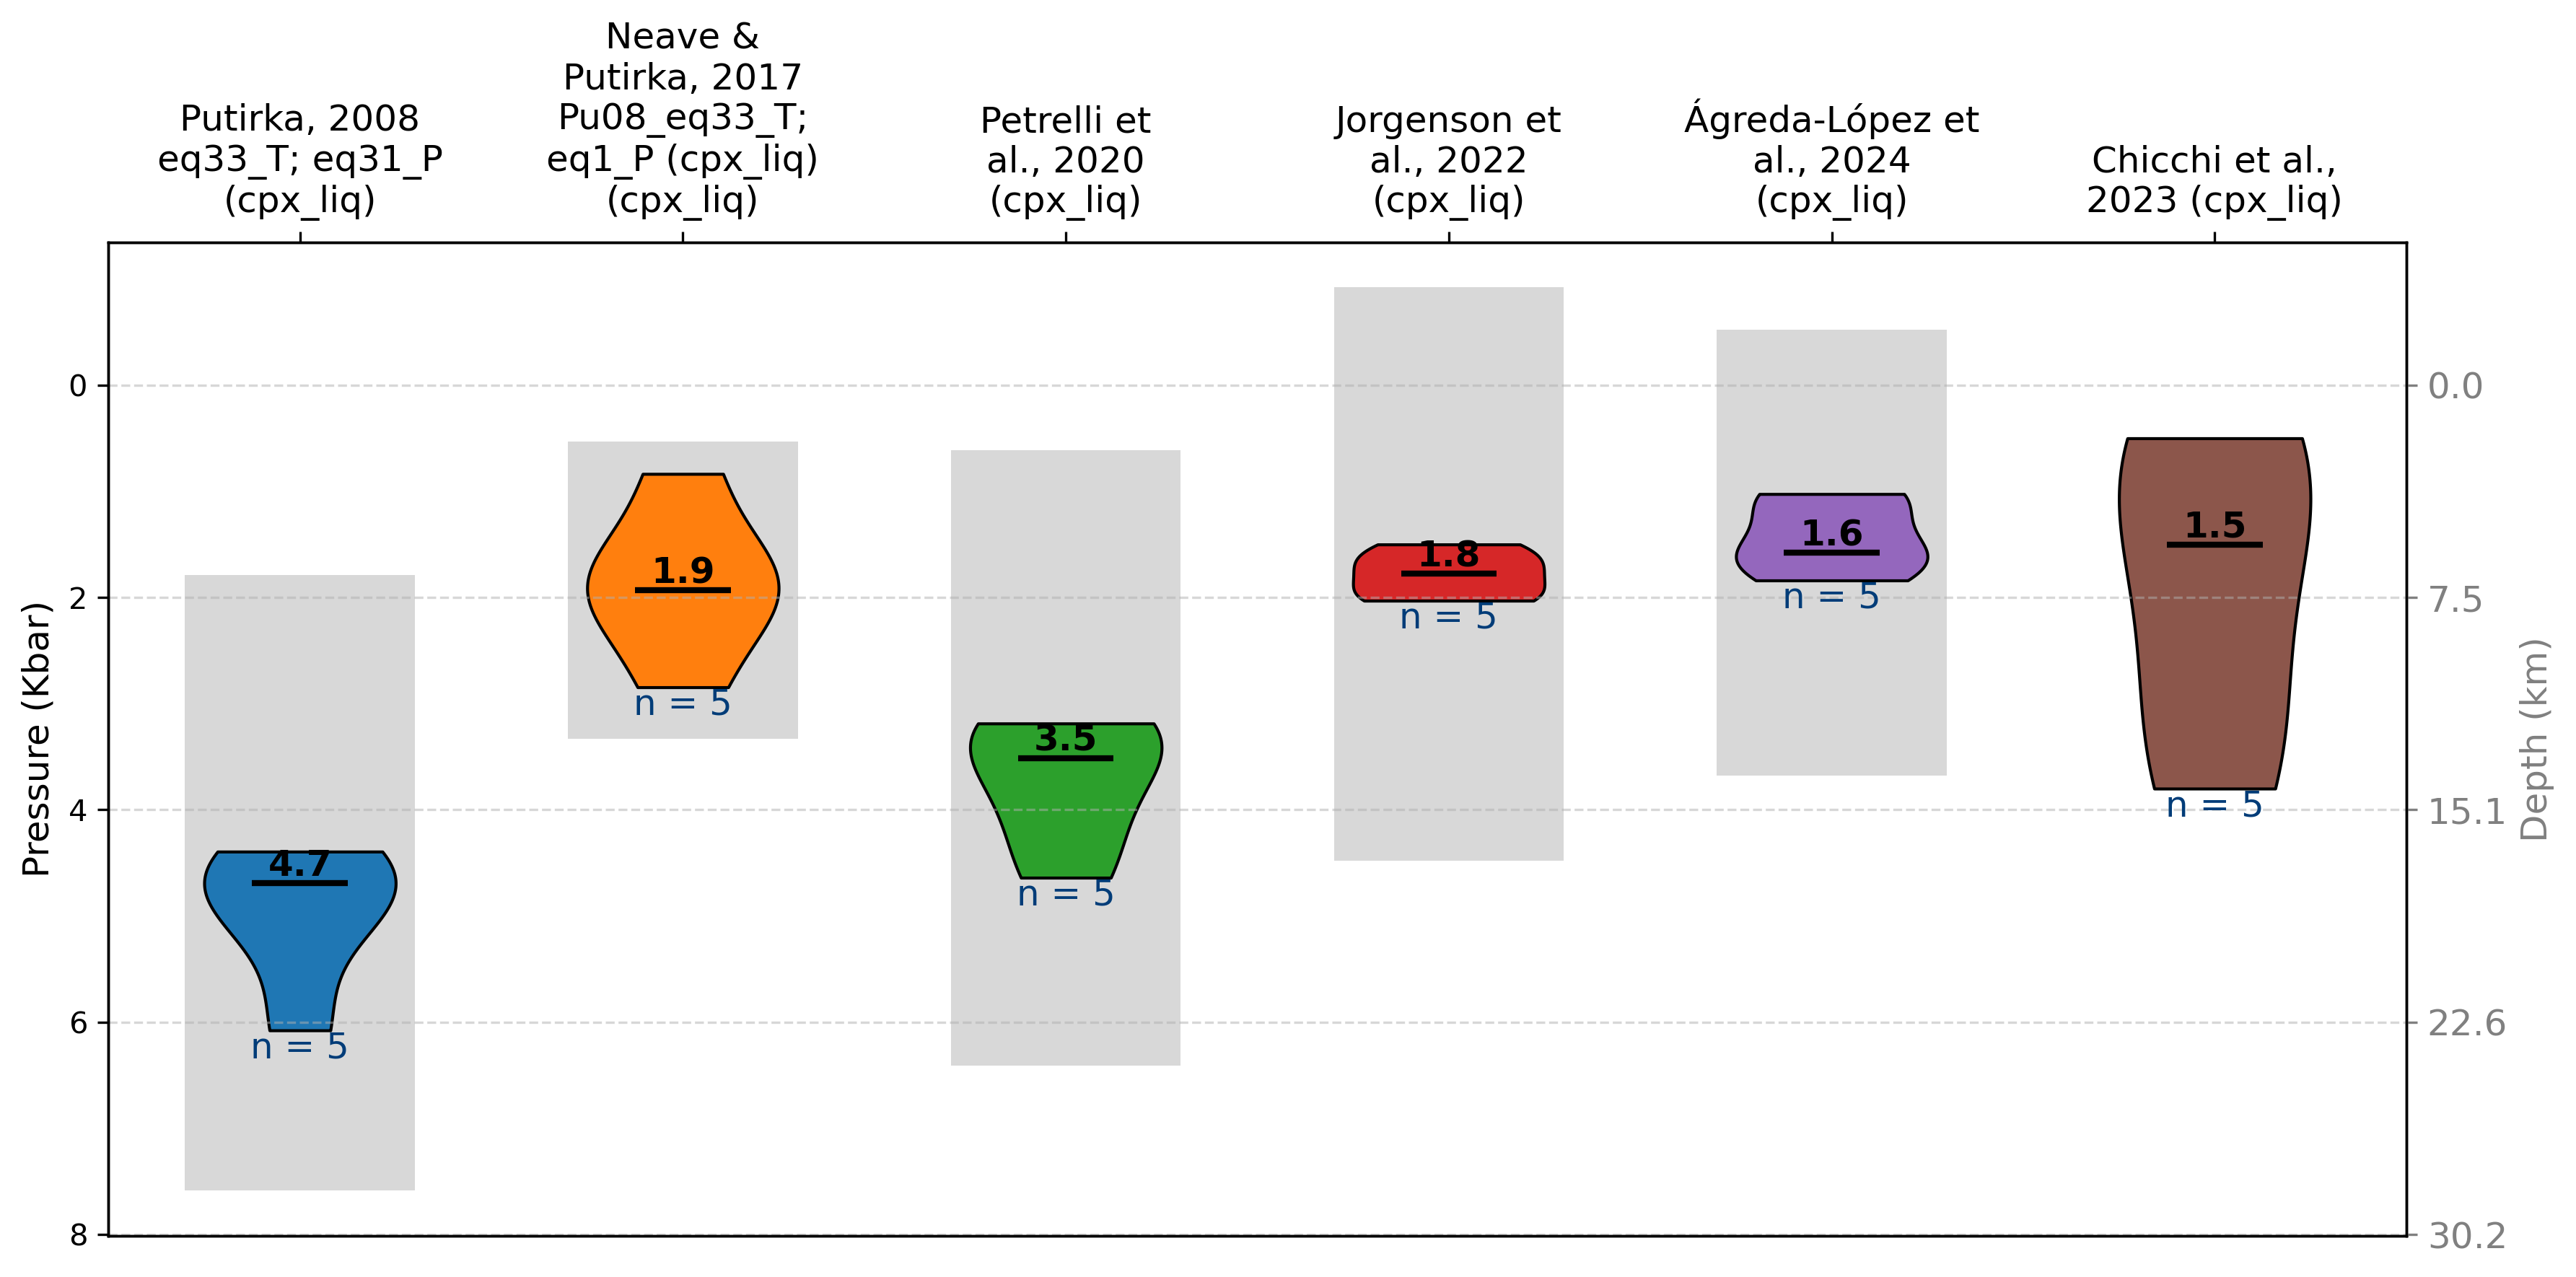

In [ ]:



P_cpx_liq_pool = [model for model in P_model_pool if not model.cpx_only]

cache_path_P_liq = os.path.join(output_dir, f"computed_cache_cpx_liq_P.pkl")


if os.path.exists(cache_path_P_liq):
    with open(cache_path_P_liq, 'rb') as f:
        framework_P_cpx_liq = pkl.load(f)
    print("Loaded existing workflow from:", cache_path_P_liq)
else:
    framework_P_cpx_liq = workflow_thermobarometry(P_cpx_liq_pool)
    framework_P_cpx_liq.predict(X_cpx, X_liq)
    with open(cache_path_P_liq, 'wb') as f:
        pkl.dump(framework_P_cpx_liq, f)
    print("Saved workflow to:", cache_path_P_liq)




report_path_P_liq = os.path.join(output_dir, f"{timestamp}_report_cpx_liq_P.xlsx")

report_excel(
    workflow_obj=framework_P_cpx_liq,
    model_list =P_cpx_liq_pool,
    original_data=input_data,
    out_path=report_path_P_liq
)


### 2.2.2. Thermometers

Saved workflow to: report_output\example_project\computed_cache_cpx_liq_T.pkl


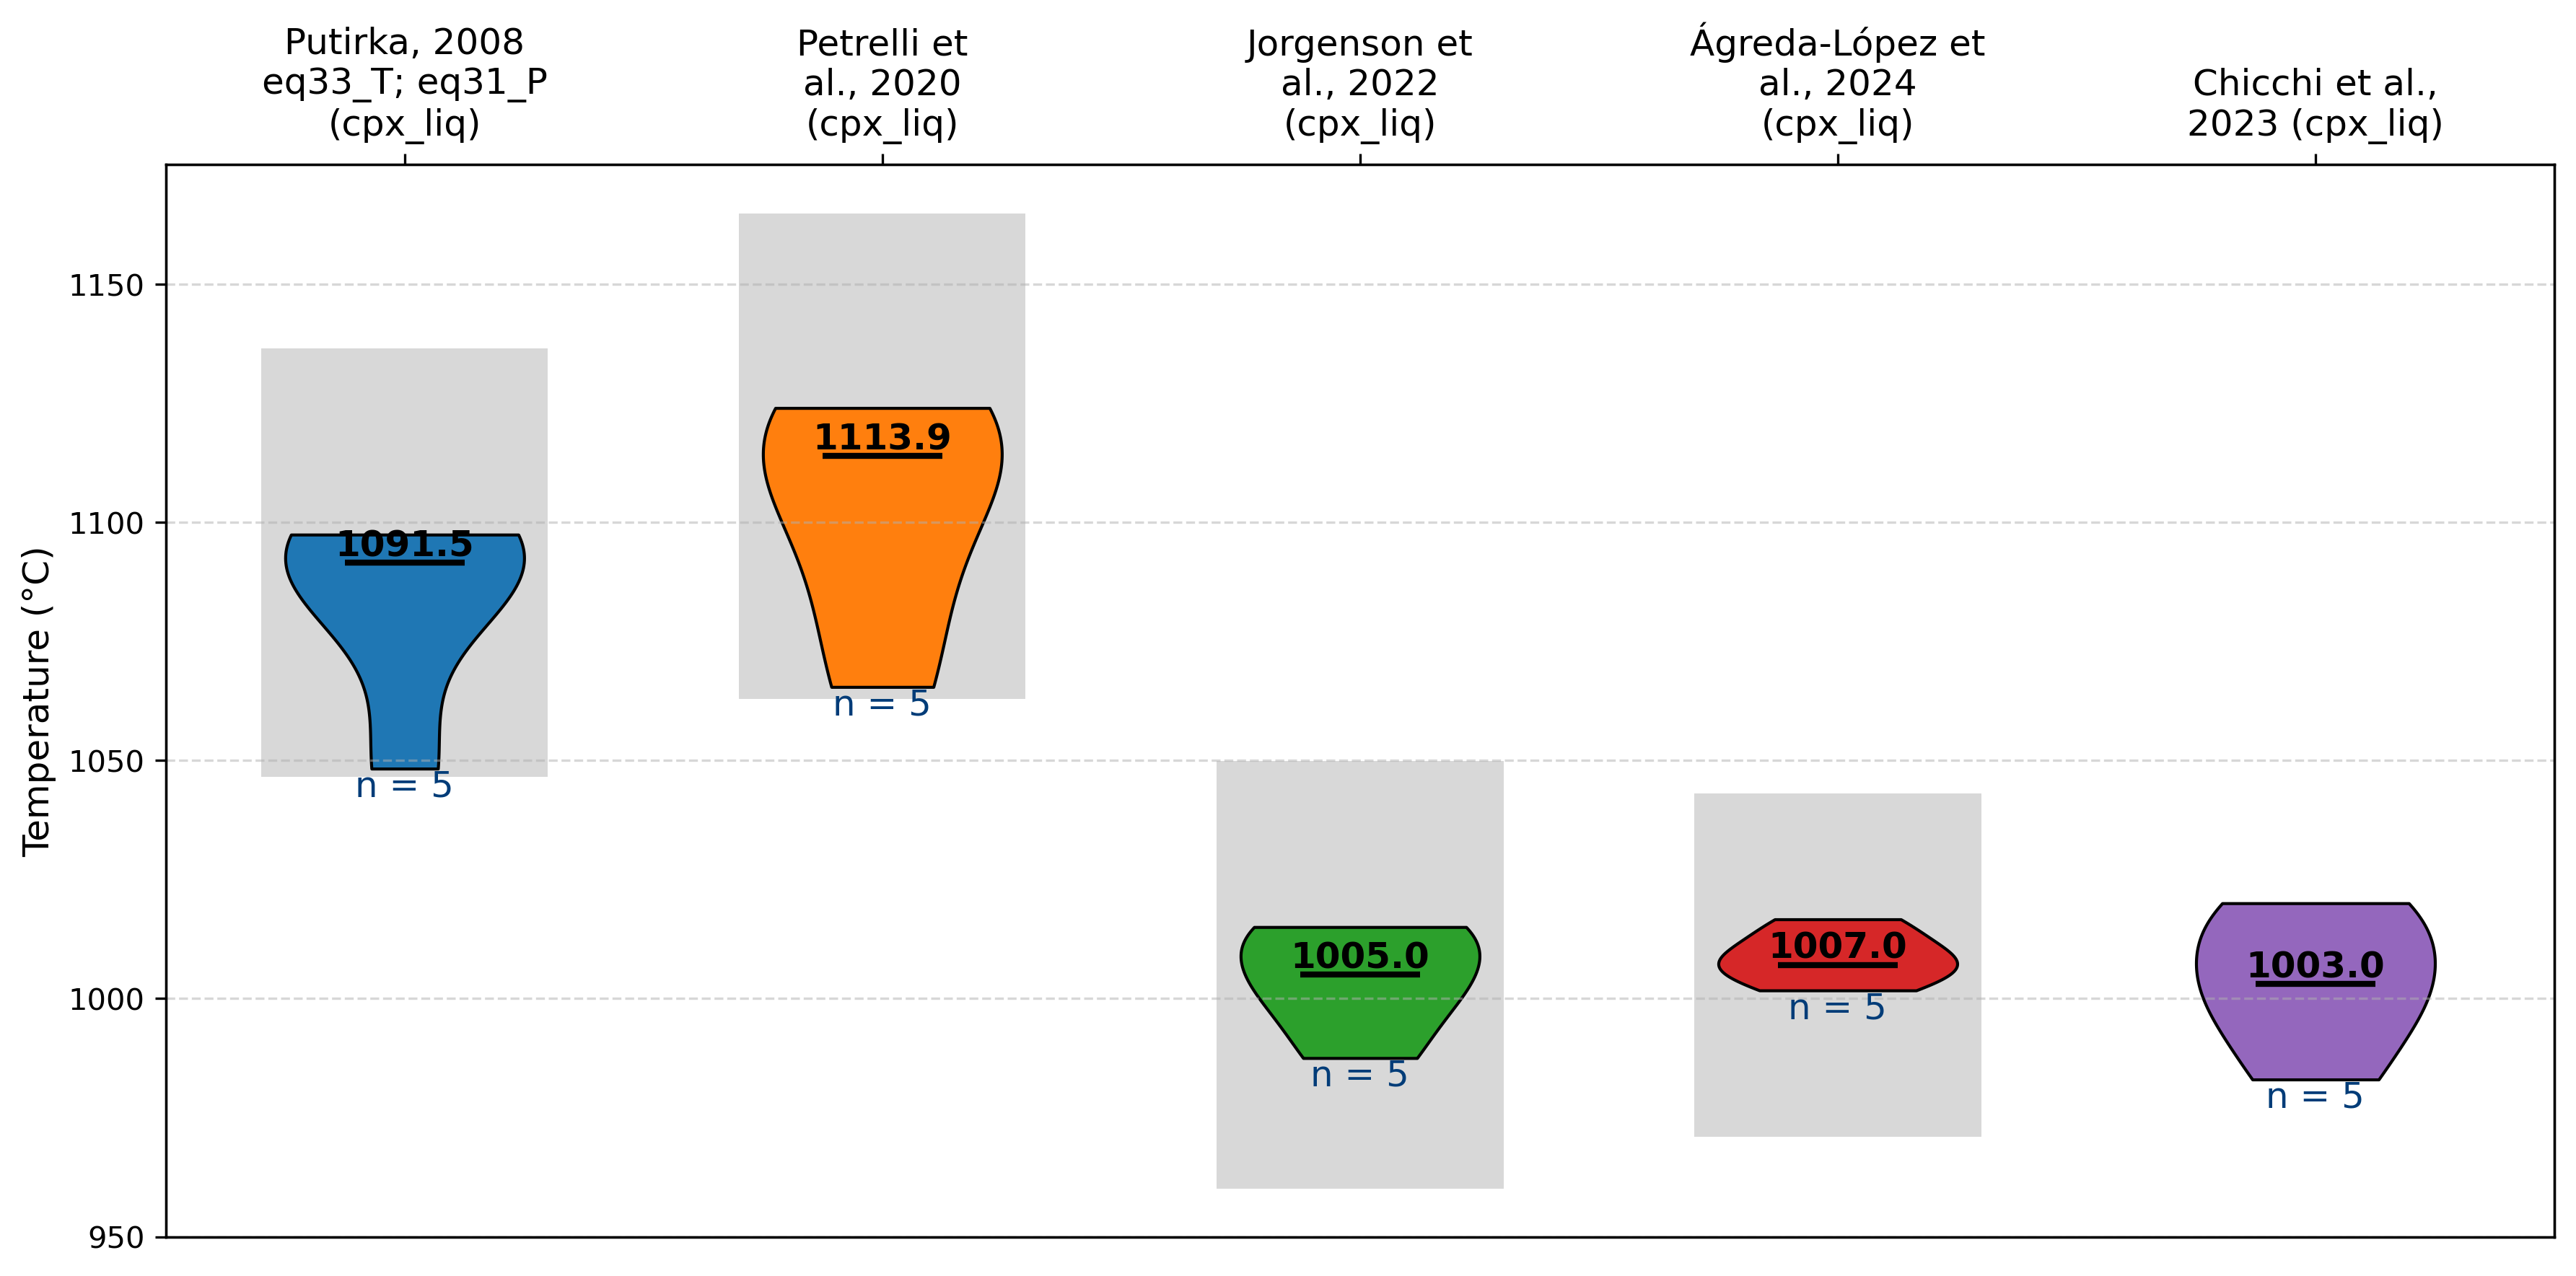

In [22]:

T_cpx_liq_pool = [model for model in T_model_pool if not model.cpx_only]

cache_path_T_liq = os.path.join(output_dir, f"computed_cache_cpx_liq_T.pkl")


if os.path.exists(cache_path_T_liq):
    with open(cache_path_T_liq, 'rb') as f:
        framework_T_cpx_liq = pkl.load(f)
    print("Loaded existing workflow from:", cache_path_T_liq)
else:
    framework_T_cpx_liq = workflow_thermobarometry(T_cpx_liq_pool)
    framework_T_cpx_liq.predict(X_cpx, X_liq)
    with open(cache_path_T_liq, 'wb') as f:
        pkl.dump(framework_T_cpx_liq, f)
    print("Saved workflow to:", cache_path_T_liq)




report_path_T_liq = os.path.join(output_dir, f"{timestamp}_report_cpx_liq_T.xlsx")

report_excel(
    workflow_obj=framework_T_cpx_liq,
    model_list =T_cpx_liq_pool,
    original_data=input_data,
    out_path=report_path_T_liq
)
